# ML3 VALIDATION

## 1. Answer the questions from the introduction

### a. What is leave-one-out? Provide limitations and strengths.

### Leave-One-Out Cross-Validation (LOOCV)

**Определение**

Leave-One-Out — это частный случай k-fold кросс-валидации, где

k=n — количество объектов в выборке.
На каждом шаге один объект используется как тестовый, а все остальные — как обучающая выборка. Процедура повторяется для каждого объекта, затем метрики усредняются.

**Преимущества**

Используется почти вся выборка для обучения на каждом шаге → малая смещённость оценки качества.

Нет зависимости от случайного разбиения — разбиения однозначно заданы.

Полезно при очень маленьком числе объектов, когда жалко «терять» данные на валидацию.

**Ограничения**

Высокая вычислительная стоимость: нужно обучить модель 
n раз.

Часто даёт оценку с высокой дисперсией (нестабильную), особенно для «шумных» данных.

Для сложных моделей или больших датасетов становится практически неиспользуемым из-за времени обучения.

### b. How do Grid Search, Randomized Grid Search, and Bayesian optimization work?

#### Grid Search (полный перебор по сетке)

**Идея**:
Заранее задаём сетку значений гиперпараметров (например, alpha ∈ {0.01, 0.1, 1}, l1_ratio ∈ {0.1, 0.5, 0.9}) и перебираем все комбинации.
Для каждой комбинации обучаем модель (обычно с кросс-валидацией) и выбираем ту, где метрика лучшая.

**Плюсы**

Простая и прозрачная реализация.

Гарантированно проверяет все указанные точки.

**Минусы**

Очень дорого по времени при большом числе гиперпараметров или широких сетках.

Много вычислений тратится на заведомо «плохие» области пространства.

#### Randomized Search (случайный поиск по сетке/распределениям)

**Идея**:

Вместо перебора всех комбинаций мы случайно выбираем ограниченное число наборов гиперпараметров из заданных распределений (или списков), например 50 или 100 комбинаций.
Для каждого набора — обучение + оценка, потом выбираем лучшую.

**Плюсы**

Часто находит почти оптимальные параметры при гораздо меньшем числе запусков.

Можно искать по широким диапазонам параметров.

Лучше масштабируется, чем Grid Search.

**Минусы**

Нет гарантии, что мы попадём в «идеальные» значения.

Результат зависит от случайной выборки (нужен random_state для воспроизводимости).

#### Байесовская оптимизация (Bayesian Optimization)

**Идея**
Относится к методам «умного» поиска.
Модель (обычно гауссовский процесс или другое суррогатное распределение) аппроксимирует зависимость:
гиперпараметры → метрика качества.

Далее алгоритм итеративно выбирает следующую точку (набор гиперпараметров), балансируя:

exploration — изучение малоизвестных областей,

exploitation — уточнение уже перспективных областей.

После каждой новой оценки метрики модель обновляет своё представление и планирует следующую точку.

**Плюсы**

Обычно быстрее и эффективнее, чем Grid/Random Search, при дорогих моделях (каждое обучение стоит дорого).

Требует меньше запусков, чтобы найти хорошие гиперпараметры.

Целенаправленно исследует пространство гиперпараметров.

**Минусы**

Сложнее в реализации и понимании.

Дополнительные накладные расходы на обучение суррогатной модели.

Может работать хуже на очень «шумных» задачах или при крайне высоком числе параметров.

### c. Explain classification of feature selection methods. Explain how Pearson and Chi2 work. Explain how Lasso works. Explain what permutation significance is. Become familiar with SHAP.

#### Методы отбора признаков можно разделить на три основные категории в зависимости от того, как они взаимодействуют с моделью машинного обучения:
1. Методы Фильтрации (Filter Methods)

    Описание: Эти методы оценивают информативность или важность признака, используя его внутренние свойства или его связь с целевой переменной, не привлекая при этом какую-либо конкретную модель машинного обучения.

    Процесс: Признаки ранжируются, и отбирается топ-К признаков.

    Преимущества: Быстры, независимы от модели, устойчивы к переобучению.

    Примеры: Хи-квадрат (χ2), коэффициент корреляции Пирсона, ANOVA, информационное приращение (Information Gain).

2. Методы Обертывания (Wrapper Methods)

    Описание: Эти методы используют конкретную модель машинного обучения в качестве "черного ящика" для оценки подмножества признаков. Они перебирают различные комбинации признаков и используют точность/производительность модели как меру качества подмножества.

    Процесс: Итеративный поиск оптимального подмножества, где модель переобучается на каждом подмножестве.

    Преимущества: Учитывают взаимосвязи между признаками, часто дают более высокую точность.

    Недостатки: Вычислительно очень затратны, подвержены переобучению.

    Примеры: Прямой пошаговый отбор (Forward Selection), Обратный пошаговый отбор (Backward Elimination), Рекурсивное исключение признаков (Recursive Feature Elimination - RFE).

3. Встроенные Методы (Embedded Methods)

    Описание: Эти методы выполняют отбор признаков как неотъемлемую часть процесса обучения модели. Они комбинируют преимущества методов фильтрации и обертывания.

    Процесс: Модель (например, линейная модель с регуляризацией) обучается, а веса или коэффициенты признаков используются для определения их важности. Признаки с нулевыми или очень маленькими весами отбрасываются.

    Преимущества: Более эффективны, чем обертывание, учитывают взаимосвязи.

    Примеры: LASSO (L1-регуляризация), Ridge (L2-регуляризация), Elastic Net, методы на основе деревьев решений (например, важность признаков в Random Forest/XGBoost).

#### Как работают Pearson и χ2 (Методы Фильтрации)
Коэффициент Корреляции Пирсона (Pearson Correlation Coefficient)

  Назначение: Мера линейной зависимости между двумя непрерывными переменными. В отборе признаков используется для оценки линейной связи между непрерывным признаком X и непрерывной целевой переменной Y.

  Принцип работы: Коэффициент r принимает значения от −1 до +1.

      r=+1: Идеальная положительная линейная корреляция.

      r=−1: Идеальная отрицательная линейная корреляция.

      r=0: Отсутствие линейной корреляции.

  Отбор: Признаки с большим абсолютным значением r (близким к −1 или +1) считаются более важными, так как они сильнее линейно связаны с целевой переменной.

#### Тест Хи-квадрат (χ2)

  Назначение: Мера независимости между двумя категориальными переменными. В отборе признаков используется для оценки связи между категориальным признаком X и категориальной целевой переменной Y (например, для задачи бинарной классификации).

  Принцип работы: χ2-статистика измеряет разницу между наблюдаемыми частотами (фактическое распределение признака по классам) и ожидаемыми частотами (распределение, которое было бы, если бы признак и целевая переменная были полностью независимы).
  χ2=∑Ei​(Oi​−Ei​)2​

      Oi​ — наблюдаемая частота; Ei​ — ожидаемая частота.

  Отбор: Большое значение χ2 указывает на сильную зависимость между признаком и целевой переменной, а следовательно, на его высокую информативность.

#### Как работает LASSO (Least Absolute Shrinkage and Selection Operator)

LASSO — это метод линейной регрессии (встроенный метод), который включает L1-регуляризацию (штраф L1) для одновременного снижения сложности модели и отбора признаков.

  Функция потерь (Objective Function): LASSO минимизирует сумму среднеквадратичной ошибки (MSE) и L1-штрафа (сумма абсолютных значений коэффициентов).
  βmin​(MSE+λj=1∑p​∣βj​∣)

      MSE (Mean Squared Error): n1​∑i=1n​(yi​−y^​i​)2

      βj​: Коэффициент при признаке j.

      λ (Лямбда): Параметр регуляризации, который контролирует силу штрафа.

  Отбор признаков: Штраф λ∑∣βj​∣ принуждает модель занулять коэффициенты (βj​=0) тех признаков, которые наименее полезны для прогнозирования.

      Если λ=0, это обычная линейная регрессия.

      С ростом λ все больше коэффициентов обнуляются.

      Признаки, чьи коэффициенты обнулены, фактически исключаются из модели, что и является отбором признаков.

#### Что такое Перестановочная Значимость (Permutation Significance/Importance)

Перестановочная значимость признака (Permutation Feature Importance - PFI) — это метод оценки важности признаков, который работает для любой обученной модели (нейронные сети, случайные леса, линейные модели и т. д.).

  Принцип работы: Метод измеряет, насколько ухудшается производительность обученной модели (например, падает точность или возрастает ошибка), когда значения одного конкретного признака случайным образом перемешиваются (переставляются).

  Процесс:

    Обучите модель и рассчитайте ее базовую производительность Sbase​ на тестовом наборе (или кросс-валидации).

    Для каждого признака Fj​:

        Случайно перемешайте (пермутируйте) значения признака Fj​ в тестовом наборе. Это разрушает связь между Fj​ и целевой переменной Y.

        Рассчитайте новую производительность модели Sperm​ на этом измененном наборе данных.

    Важность признака Fj​ определяется как разница или отношение: Importancej​=Sbase​−Sperm​.

  Интерпретация: Если при перемешивании признака Fj​ производительность модели сильно падает (разница велика), то признак Fj​ важен. Если производительность почти не меняется, признак Fj​ неважен.

#### Знакомство с SHAP (SHapley Additive exPlanations)

SHAP — это метод, основанный на теории игр, который используется для интерпретации прогнозов сложных моделей машинного обучения (eXplainable AI, XAI). Он вычисляет вклад каждого признака в конкретный прогноз.

  Основа: SHAP использует значения Шепли (Shapley values) из теории кооперативных игр. Значение Шепли — это способ справедливого распределения "выигрыша" (разницы между фактическим прогнозом и базовым прогнозом, например, средним) между "игроками" (признаками).

  Аддитивная модель объяснения: SHAP представляет объяснение в виде аддитивной модели, где вклад каждого признака суммируется для получения окончательного прогноза.

  Ключевая особенность: SHAP гарантирует, что вклад каждого признака учитывает все возможные комбинации (коалиции) признаков. Это делает его единственным методом, который обладает такими желательными свойствами, как локальная точность, пропущенность и согласованность.

  Формула (концептуально): Значение SHAP для признака j — это средний вклад, который он вносит в прогноз по всем возможным порядкам его добавления к модели:
  ϕj​(f,x)=S⊆N∖{j}∑​∣N∣!∣S∣!(∣N∣−∣S∣−1)!​[fx​(S∪{j})−fx​(S)]

    ϕj​: Значение SHAP для признака j.

    fx​(S): Прогноз модели с использованием подмножества признаков S.

  Применение:

    Локальная интерпретация: Объяснение, почему конкретный экземпляр (одна строка данных) получил такой прогноз.

    Глобальная интерпретация: Оценка общей важности признаков в модели (аналогично перестановочной значимости).

## 2. Introduction — do all the preprocessing from the previous lesson

In [925]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter
import random
import datetime
import time

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.preprocessing import MinMaxScaler, StandardScaler, PolynomialFeatures

from dataset_split_methods import my_train_test_split
from cross_validation_methods import my_KFold, my_GroupKFold, my_StratifiedKFold, my_TimeSeriesSplit

In [926]:
RANDOM_SEED = 21

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

### a. Read all the data.

In [927]:
df = pd.read_json("./data/train.json", convert_dates=["created"], orient="columns")
df.reset_index(drop=True, inplace=True)
df.head(3)

,bathrooms,bedrooms,building_id,created,description,display_address,features,latitude,listing_id,longitude,manager_id,photos,price,street_address,interest_level
0,1.0,1,8579a0b0d54db803821a35a4a615e97a,2016-06-16 05:55:27,Spacious 1 Bedroom 1 Bathroom in Williamsburg!...,145 Borinquen Place,"[Dining Room, Pre-War, Laundry in Building, Di...",40.7108,7170325,-73.9539,a10db4590843d78c784171a107bdacb4,[https://photos.renthop.com/2/7170325_3bb5ac84...,2400,145 Borinquen Place,medium
1,1.0,2,b8e75fc949a6cd8225b455648a951712,2016-06-01 05:44:33,BRAND NEW GUT RENOVATED TRUE 2 BEDROOMFind you...,East 44th,"[Doorman, Elevator, Laundry in Building, Dishw...",40.7513,7092344,-73.9722,955db33477af4f40004820b4aed804a0,[https://photos.renthop.com/2/7092344_7663c19a...,3800,230 East 44th,low
2,1.0,2,cd759a988b8f23924b5a2058d5ab2b49,2016-06-14 15:19:59,**FLEX 2 BEDROOM WITH FULL PRESSURIZED WALL**L...,East 56th Street,"[Doorman, Elevator, Laundry in Building, Laund...",40.7575,7158677,-73.9625,c8b10a317b766204f08e613cef4ce7a0,[https://photos.renthop.com/2/7158677_c897a134...,3495,405 East 56th Street,medium


### b. Preprocess the "Interest Level" feature.

In [928]:
interest_level_encoder = {"low": 0, "medium": 1, "high": 2}
df["interest_level"] = df["interest_level"].map(interest_level_encoder)
df.head(3)

,bathrooms,bedrooms,building_id,created,description,display_address,features,latitude,listing_id,longitude,manager_id,photos,price,street_address,interest_level
0,1.0,1,8579a0b0d54db803821a35a4a615e97a,2016-06-16 05:55:27,Spacious 1 Bedroom 1 Bathroom in Williamsburg!...,145 Borinquen Place,"[Dining Room, Pre-War, Laundry in Building, Di...",40.7108,7170325,-73.9539,a10db4590843d78c784171a107bdacb4,[https://photos.renthop.com/2/7170325_3bb5ac84...,2400,145 Borinquen Place,1
1,1.0,2,b8e75fc949a6cd8225b455648a951712,2016-06-01 05:44:33,BRAND NEW GUT RENOVATED TRUE 2 BEDROOMFind you...,East 44th,"[Doorman, Elevator, Laundry in Building, Dishw...",40.7513,7092344,-73.9722,955db33477af4f40004820b4aed804a0,[https://photos.renthop.com/2/7092344_7663c19a...,3800,230 East 44th,0
2,1.0,2,cd759a988b8f23924b5a2058d5ab2b49,2016-06-14 15:19:59,**FLEX 2 BEDROOM WITH FULL PRESSURIZED WALL**L...,East 56th Street,"[Doorman, Elevator, Laundry in Building, Laund...",40.7575,7158677,-73.9625,c8b10a317b766204f08e613cef4ce7a0,[https://photos.renthop.com/2/7158677_c897a134...,3495,405 East 56th Street,1


### c. Create features: 'Elevator', 'HardwoodFloors', 'CatsAllowed', 'DogsAllowed', 'Doorman', 'Dishwasher', 'NoFee', 'LaundryinBuilding', 'FitnessCenter', 'Pre-War', 'LaundryinUnit', 'RoofDeck', 'OutdoorSpace', 'DiningRoom', 'HighSpeedInternet', 'Balcony', 'SwimmingPool', 'LaundryInBuilding', 'NewConstruction', 'Terrace'.

In [929]:
df["features"]

0        [Dining Room, Pre-War, Laundry in Building, Di...
1        [Doorman, Elevator, Laundry in Building, Dishw...
2        [Doorman, Elevator, Laundry in Building, Laund...
3                                                       []
4        [Doorman, Elevator, Fitness Center, Laundry in...
                               ...                        
49347              [Elevator, Dishwasher, Hardwood Floors]
49348    [Common Outdoor Space, Cats Allowed, Dogs Allo...
49349    [Dining Room, Elevator, Pre-War, Laundry in Bu...
49350    [Pre-War, Laundry in Unit, Dishwasher, No Fee,...
49351    [Dining Room, Elevator, Laundry in Building, D...
Name: features, Length: 49352, dtype: object

In [930]:
df["features_clean"] = df["features"].apply(
    lambda array: [item.replace(" ", "") for item in array]
)
df["features_clean"]

0        [DiningRoom, Pre-War, LaundryinBuilding, Dishw...
1        [Doorman, Elevator, LaundryinBuilding, Dishwas...
2        [Doorman, Elevator, LaundryinBuilding, Laundry...
3                                                       []
4        [Doorman, Elevator, FitnessCenter, LaundryinBu...
                               ...                        
49347               [Elevator, Dishwasher, HardwoodFloors]
49348    [CommonOutdoorSpace, CatsAllowed, DogsAllowed,...
49349    [DiningRoom, Elevator, Pre-War, LaundryinBuild...
49350    [Pre-War, LaundryinUnit, Dishwasher, NoFee, Ou...
49351    [DiningRoom, Elevator, LaundryinBuilding, Dish...
Name: features_clean, Length: 49352, dtype: object

In [931]:
feature_set = {
    "Elevator",
    "HardwoodFloors",
    "CatsAllowed",
    "DogsAllowed",
    "Doorman",
    "Dishwasher",
    "NoFee",
    "LaundryinBuilding",
    "FitnessCenter",
    "Pre-War",
    "LaundryinUnit",
    "RoofDeck",
    "OutdoorSpace",
    "DiningRoom",
    "HighSpeedInternet",
    "Balcony",
    "SwimmingPool",
    "LaundryInBuilding",
    "NewConstruction",
    "Terrace",
}

In [932]:
for feature in feature_set:
    df[feature] = df["features_clean"].apply(lambda lst: int(feature in lst))
df.head(3)

,bathrooms,bedrooms,building_id,created,description,display_address,features,latitude,listing_id,longitude,...,SwimmingPool,DogsAllowed,Elevator,Pre-War,Dishwasher,RoofDeck,FitnessCenter,HardwoodFloors,LaundryinUnit,LaundryInBuilding
0,1.0,1,8579a0b0d54db803821a35a4a615e97a,2016-06-16 05:55:27,Spacious 1 Bedroom 1 Bathroom in Williamsburg!...,145 Borinquen Place,"[Dining Room, Pre-War, Laundry in Building, Di...",40.7108,7170325,-73.9539,...,0,1,0,1,1,0,0,1,0,0
1,1.0,2,b8e75fc949a6cd8225b455648a951712,2016-06-01 05:44:33,BRAND NEW GUT RENOVATED TRUE 2 BEDROOMFind you...,East 44th,"[Doorman, Elevator, Laundry in Building, Dishw...",40.7513,7092344,-73.9722,...,0,0,1,0,1,0,0,1,0,0
2,1.0,2,cd759a988b8f23924b5a2058d5ab2b49,2016-06-14 15:19:59,**FLEX 2 BEDROOM WITH FULL PRESSURIZED WALL**L...,East 56th Street,"[Doorman, Elevator, Laundry in Building, Laund...",40.7575,7158677,-73.9625,...,0,0,1,0,1,0,0,1,1,0


In [933]:
df = df.drop(
    [
        "building_id",
        "description",
        "display_address",
        "features",
        "features_clean",
        "latitude",
        "longitude",
        "listing_id",
        "manager_id",
        "photos",
        "street_address",
    ],
    axis=1,
)
df.head(5)

,bathrooms,bedrooms,created,price,interest_level,Terrace,CatsAllowed,Doorman,LaundryinBuilding,HighSpeedInternet,...,SwimmingPool,DogsAllowed,Elevator,Pre-War,Dishwasher,RoofDeck,FitnessCenter,HardwoodFloors,LaundryinUnit,LaundryInBuilding
0,1.0,1,2016-06-16 05:55:27,2400,1,0,1,0,1,0,...,0,1,0,1,1,0,0,1,0,0
1,1.0,2,2016-06-01 05:44:33,3800,0,0,0,1,1,0,...,0,0,1,0,1,0,0,1,0,0
2,1.0,2,2016-06-14 15:19:59,3495,1,0,0,1,1,0,...,0,0,1,0,1,0,0,1,1,0
3,1.5,3,2016-06-24 07:54:24,3000,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1.0,0,2016-06-28 03:50:23,2795,0,0,0,1,1,0,...,0,0,1,0,0,0,1,0,0,0


### Выбросы

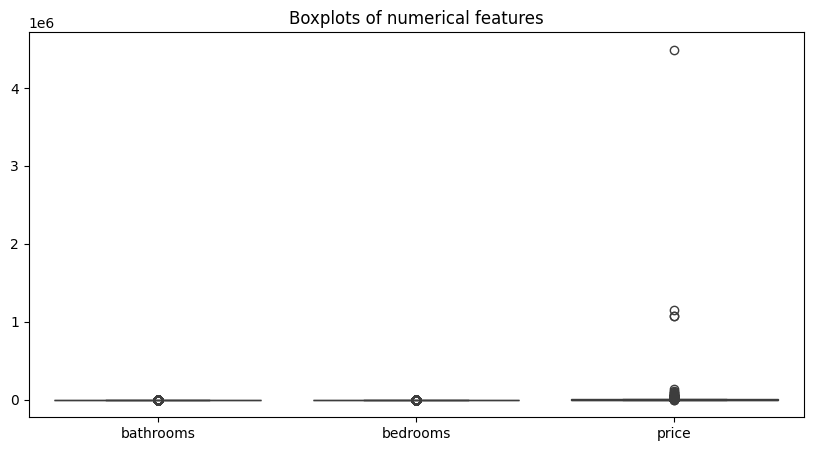

In [934]:
numeric_cols = ["bathrooms", "bedrooms", "price"]
plt.figure(figsize=(10, 5))
sns.boxplot(data=df[numeric_cols])
plt.title("Boxplots of numerical features")
plt.show()

In [935]:
Q1 = df["price"].quantile(0.25)
Q3 = df["price"].quantile(0.75)
print(f"Q1:{Q1}, Q3:{Q3}")

IQR = Q3 - Q1
print(f"IQR:{IQR}")

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
print(f"lower:{lower}, upper:{upper}")

df_filtered = df[(df["price"] >= lower) & (df["price"] <= upper)].copy()

Q1:2500.0, Q3:4100.0
IQR:1600.0
lower:100.0, upper:6500.0


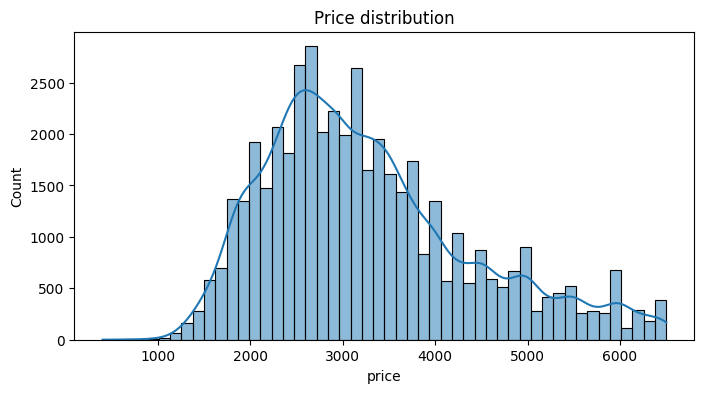

In [936]:
plt.figure(figsize=(8, 4))
sns.histplot(df_filtered["price"], bins=50, kde=True)
plt.title("Price distribution")
plt.show()

## 3. Implement the next methods

### a. Split data into 2 parts randomly with parameter test_size (ratio from 0 to 1), return training and test samples.

### b. Randomly split data into 3 parts with parameters validation_size and test_size, return train, validation and test samples.

### c. Split data into 2 parts with parameter date_split, return train and test samples split by date_split param.

### d. Split data into 3 parts with parameters validation_date and test_date, return train, validation and test samples split by input params.

In [937]:
# Создаем тестовые данные
X = np.array([[1, 2], [3, 4], [5, 6], [7, 8], [9, 10], 
                [11, 12], [13, 14], [15, 16], [17, 18], [19, 20]])
y = np.array([0, 1, 0, 1, 0, 1, 0, 1, 0, 1])

print("Исходные данные:")
print("X shape:", X.shape)
print("y shape:", y.shape)
print()

Исходные данные:
X shape: (10, 2)
y shape: (10,)



In [938]:
# Пример 1: Разделение на train и test (без validation)
print("=" * 50)
print("Пример 1: Train-Test Split (30% test)")
print("=" * 50)
X_train, X_test, y_train, y_test = my_train_test_split(X, y, test_size=0.3, random_state=21)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)
print()

Пример 1: Train-Test Split (30% test)
X_train shape: (7, 2)
X_test shape: (3, 2)
y_train shape: (7,)
y_test shape: (3,)



In [939]:
# Пример 2: Разделение на train, validation и test
print("=" * 50)
print("Пример 2: Train-Validation-Test Split (20% test, 20% validation)")
print("=" * 50)
X_train, X_val, X_test, y_train, y_val, y_test = my_train_test_split(
    X, y, test_size=0.2, validation_size=0.2, random_state=21
)

print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_val shape:", y_val.shape)
print("y_test shape:", y_test.shape)
print()

Пример 2: Train-Validation-Test Split (20% test, 20% validation)
X_train shape: (6, 2)
X_val shape: (2, 2)
X_test shape: (2, 2)
y_train shape: (6,)
y_val shape: (2,)
y_test shape: (2,)



In [940]:
# Пример 3: Разделение по дате
print("=" * 50)
print("Пример 3: Date-Based Split")
print("=" * 50)

# Создаем данные с датами
dates = pd.date_range('2024-01-01', periods=10, freq='D')
X_with_dates = pd.DataFrame({
    'date': dates,
    'feature1': [1, 3, 5, 7, 9, 11, 13, 15, 17, 19],
    'feature2': [2, 4, 6, 8, 10, 12, 14, 16, 18, 20]
})

print("X_with_dates:")
print(X_with_dates)
print()

# Разделяем по дате (данные до 2024-01-06 в train, после - в test)
X_train, X_test, y_train, y_test = my_train_test_split(
    X_with_dates, y, date_split='2024-01-06', date_column='date'
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("\nX_train:")
print(X_train)
print("\nX_test:")
print(X_test)
print("\ny_train:", y_train)
print("y_test:", y_test)

Пример 3: Date-Based Split
X_with_dates:
        date  feature1  feature2
0 2024-01-01         1         2
1 2024-01-02         3         4
2 2024-01-03         5         6
3 2024-01-04         7         8
4 2024-01-05         9        10
5 2024-01-06        11        12
6 2024-01-07        13        14
7 2024-01-08        15        16
8 2024-01-09        17        18
9 2024-01-10        19        20

X_train shape: (5, 3)
X_test shape: (5, 3)

X_train:
        date  feature1  feature2
0 2024-01-01         1         2
1 2024-01-02         3         4
2 2024-01-03         5         6
3 2024-01-04         7         8
4 2024-01-05         9        10

X_test:
        date  feature1  feature2
0 2024-01-06        11        12
1 2024-01-07        13        14
2 2024-01-08        15        16
3 2024-01-09        17        18
4 2024-01-10        19        20

y_train: [0 1 0 1 0]
y_test: [1 0 1 0 1]


### e. Make split procedure determenistic. What does it mean?

Детерминированность сплитам дает установка random.seed в конкретное значение, например 21. В нашем решении seed устанавливается в самом начале + в самих методах

## 4. Implement the next cross-validation methods:

### a. K-Fold, where k is the input parameter, returns a list of train and test indices.

In [941]:
# Пример 1: Базовое использование с numpy array
print("=" * 60)
print("Пример 1: K-Fold с k=5 на 100 сэмплах")
print("=" * 60)

X = np.arange(100)
folds = my_KFold(X, k=5, random_state=21)

for i, (train_idx, test_idx) in enumerate(folds):
    print(f"\nФолд {i+1}:")
    print(f"  Train: размер={len(train_idx)}, индексы={train_idx[:5]}...{train_idx[-5:]}")
    print(f"  Test:  размер={len(test_idx)}, индексы={test_idx[:5]}...{test_idx[-5:]}")

# Проверка: каждый индекс должен появиться ровно 1 раз в test
all_test_indices = np.concatenate([test_idx for _, test_idx in folds])
print(f"\nВсе test индексы уникальны: {len(all_test_indices) == len(np.unique(all_test_indices))}")
print(f"Покрыты все индексы: {len(np.unique(all_test_indices)) == 100}")

Пример 1: K-Fold с k=5 на 100 сэмплах

Фолд 1:
  Train: размер=80, индексы=[19  1  3 16 17]...[48  4 56 79 73]
  Test:  размер=20, индексы=[23 81 85 34 62]...[68 27 36 86 40]

Фолд 2:
  Train: размер=80, индексы=[23 81 85 34 62]...[48  4 56 79 73]
  Test:  размер=20, индексы=[19  1  3 16 17]...[67 92 65 47 24]

Фолд 3:
  Train: размер=80, индексы=[23 81 85 34 62]...[48  4 56 79 73]
  Test:  размер=20, индексы=[55 39  8 71  7]...[83 30 78 96 91]

Фолд 4:
  Train: размер=80, индексы=[23 81 85 34 62]...[48  4 56 79 73]
  Test:  размер=20, индексы=[54 57 43 64 99]...[87 82 50 70 18]

Фолд 5:
  Train: размер=80, индексы=[23 81 85 34 62]...[87 82 50 70 18]
  Test:  размер=20, индексы=[ 5 41 97 76 20]...[48  4 56 79 73]

Все test индексы уникальны: True
Покрыты все индексы: True


In [942]:
# Пример 2: Неравномерное разбиение
print("\n" + "=" * 60)
print("Пример 2: K-Fold с k=3 на 10 сэмплах (неравномерное разбиение)")
print("=" * 60)

X = list(range(10))  # Работает и с обычным list
folds = my_KFold(X, k=3, shuffle=False)

for i, (train_idx, test_idx) in enumerate(folds):
    print(f"\nФолд {i+1}:")
    print(f"  Train индексы: {train_idx}")
    print(f"  Test индексы:  {test_idx}")


Пример 2: K-Fold с k=3 на 10 сэмплах (неравномерное разбиение)

Фолд 1:
  Train индексы: [4 5 6 7 8 9]
  Test индексы:  [0 1 2 3]

Фолд 2:
  Train индексы: [0 1 2 3 7 8 9]
  Test индексы:  [4 5 6]

Фолд 3:
  Train индексы: [0 1 2 3 4 5 6]
  Test индексы:  [7 8 9]


In [943]:
# Пример 3: Сравнение с shuffle=True и shuffle=False
print("\n" + "=" * 60)
print("Пример 3: Shuffle vs No Shuffle")
print("=" * 60)

X = np.arange(15)

print("\nБез перемешивания (shuffle=False):")
folds_no_shuffle = my_KFold(X, k=3, shuffle=False)
for i, (_, test_idx) in enumerate(folds_no_shuffle):
    print(f"  Fold {i+1} test: {test_idx}")

print("\nС перемешиванием (shuffle=True, random_state=21):")
folds_shuffle = my_KFold(X, k=3, shuffle=True, random_state=21)
for i, (_, test_idx) in enumerate(folds_shuffle):
    print(f"  Fold {i+1} test: {test_idx}")


Пример 3: Shuffle vs No Shuffle

Без перемешивания (shuffle=False):
  Fold 1 test: [0 1 2 3 4]
  Fold 2 test: [5 6 7 8 9]
  Fold 3 test: [10 11 12 13 14]

С перемешиванием (shuffle=True, random_state=21):
  Fold 1 test: [14  5  7 10  6]
  Fold 2 test: [ 1  2 12  3 13]
  Fold 3 test: [11  0  4  8  9]


### b. Grouped K-Fold, where k and group_field are input parameters, returns list of train and test indices.

In [944]:
# Пример 1: Базовое использование
print("=" * 70)
print("Пример 1: Grouped K-Fold с пользователями")
print("=" * 70)

# У нас есть 20 сэмплов от 8 разных пользователей
X = np.arange(20)
# Каждое число - это ID пользователя (у некоторых пользователей несколько сэмплов)
groups = np.array([1, 1, 1, 2, 2, 3, 3, 3, 3, 4, 4, 5, 5, 5, 6, 6, 7, 7, 7, 8])

print(f"\nВсего сэмплов: {len(X)}")
print(f"Уникальных пользователей: {len(np.unique(groups))}")
print(f"Группы: {groups}")

folds = my_GroupKFold(X, groups, k=4, random_state=21)

for i, (train_idx, test_idx) in enumerate(folds):
    train_groups = groups[train_idx]
    test_groups = groups[test_idx]
    
    print(f"\n--- Фолд {i+1} ---")
    print(f"Train: {len(train_idx)} сэмплов, пользователи: {sorted(np.unique(train_groups))}")
    print(f"Test:  {len(test_idx)} сэмплов, пользователи: {sorted(np.unique(test_groups))}")
    
    # Проверка: нет пересечения групп между train и test
    intersection = set(train_groups) & set(test_groups)
    print(f"Пересечение групп: {intersection if intersection else 'Нет ✓'}")

Пример 1: Grouped K-Fold с пользователями

Всего сэмплов: 20
Уникальных пользователей: 8
Группы: [1 1 1 2 2 3 3 3 3 4 4 5 5 5 6 6 7 7 7 8]

--- Фолд 1 ---
Train: 15 сэмплов, пользователи: [np.int64(1), np.int64(2), np.int64(4), np.int64(5), np.int64(6), np.int64(7)]
Test:  5 сэмплов, пользователи: [np.int64(3), np.int64(8)]
Пересечение групп: Нет ✓

--- Фолд 2 ---
Train: 15 сэмплов, пользователи: [np.int64(1), np.int64(2), np.int64(3), np.int64(5), np.int64(6), np.int64(8)]
Test:  5 сэмплов, пользователи: [np.int64(4), np.int64(7)]
Пересечение групп: Нет ✓

--- Фолд 3 ---
Train: 15 сэмплов, пользователи: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(7), np.int64(8)]
Test:  5 сэмплов, пользователи: [np.int64(5), np.int64(6)]
Пересечение групп: Нет ✓

--- Фолд 4 ---
Train: 15 сэмплов, пользователи: [np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
Test:  5 сэмплов, пользователи: [np.int64(1), np.int64(2)]
Пересечение групп: Нет ✓


### c. Stratified K-fold, where k and stratify_field are input parameters, returns list of train and test indices.

In [945]:
# Пример 1: Несбалансированный датасет (классическое применение)
print("=" * 70)
print("Пример 1: Несбалансированный датасет (80% класс 0, 20% класс 1)")
print("=" * 70)

n_samples = 100
X = np.arange(n_samples)
# Несбалансированные классы: 80 сэмплов класса 0, 20 сэмплов класса 1
y = np.array([0]*80 + [1]*20)

print(f"\nОбщее распределение классов:")
print(f"  Класс 0: {np.sum(y == 0)} ({np.sum(y == 0)/len(y)*100:.1f}%)")
print(f"  Класс 1: {np.sum(y == 1)} ({np.sum(y == 1)/len(y)*100:.1f}%)")

folds = my_StratifiedKFold(X, y, k=5, random_state=42)

print(f"\nРаспределение по фолдам:")
for i, (train_idx, test_idx) in enumerate(folds):
    y_train = y[train_idx]
    y_test = y[test_idx]
    
    test_class_0 = np.sum(y_test == 0)
    test_class_1 = np.sum(y_test == 1)
    
    print(f"\n--- Фолд {i+1} ---")
    print(f"Train: {len(train_idx)} сэмплов, класс 0: {np.sum(y_train == 0)}, класс 1: {np.sum(y_train == 1)}")
    print(f"Test:  {len(test_idx)} сэмплов, класс 0: {test_class_0} ({test_class_0/len(test_idx)*100:.1f}%), "
            f"класс 1: {test_class_1} ({test_class_1/len(test_idx)*100:.1f}%)")

Пример 1: Несбалансированный датасет (80% класс 0, 20% класс 1)

Общее распределение классов:
  Класс 0: 80 (80.0%)
  Класс 1: 20 (20.0%)

Распределение по фолдам:

--- Фолд 1 ---
Train: 80 сэмплов, класс 0: 64, класс 1: 16
Test:  20 сэмплов, класс 0: 16 (80.0%), класс 1: 4 (20.0%)

--- Фолд 2 ---
Train: 80 сэмплов, класс 0: 64, класс 1: 16
Test:  20 сэмплов, класс 0: 16 (80.0%), класс 1: 4 (20.0%)

--- Фолд 3 ---
Train: 80 сэмплов, класс 0: 64, класс 1: 16
Test:  20 сэмплов, класс 0: 16 (80.0%), класс 1: 4 (20.0%)

--- Фолд 4 ---
Train: 80 сэмплов, класс 0: 64, класс 1: 16
Test:  20 сэмплов, класс 0: 16 (80.0%), класс 1: 4 (20.0%)

--- Фолд 5 ---
Train: 80 сэмплов, класс 0: 64, класс 1: 16
Test:  20 сэмплов, класс 0: 16 (80.0%), класс 1: 4 (20.0%)


In [946]:
# Пример 2: Крайне несбалансированный случай
print("\n" + "=" * 70)
print("Пример 2: Крайне несбалансированный датасет")
print("=" * 70)

# 95% одного класса, 5% другого
X = np.arange(200)
y = np.array([0]*190 + [1]*10)

print(f"Датасет: 190 сэмплов класса 0 (95%), 10 сэмплов класса 1 (5%)")

folds = my_StratifiedKFold(X, y, k=5, random_state=42)

print(f"\nРаспределение по фолдам:")
for i, (train_idx, test_idx) in enumerate(folds):
    y_test = y[test_idx]
    count_0 = np.sum(y_test == 0)
    count_1 = np.sum(y_test == 1)
    
    print(f"Фолд {i+1}: test size={len(test_idx)}, "
            f"класс 0: {count_0} ({count_0/len(test_idx)*100:.1f}%), "
            f"класс 1: {count_1} ({count_1/len(test_idx)*100:.1f}%)")

# Проверка: каждый сэмпл класса 1 должен быть в test ровно 1 раз
minority_class_indices = np.where(y == 1)[0]
test_appearances = {idx: 0 for idx in minority_class_indices}

for train_idx, test_idx in folds:
    for idx in test_idx:
        if idx in test_appearances:
            test_appearances[idx] += 1

print(f"\nКаждый сэмпл меньшинства класса появляется в test ровно 1 раз: "
        f"{all(count == 1 for count in test_appearances.values())}")


Пример 2: Крайне несбалансированный датасет
Датасет: 190 сэмплов класса 0 (95%), 10 сэмплов класса 1 (5%)

Распределение по фолдам:
Фолд 1: test size=40, класс 0: 38 (95.0%), класс 1: 2 (5.0%)
Фолд 2: test size=40, класс 0: 38 (95.0%), класс 1: 2 (5.0%)
Фолд 3: test size=40, класс 0: 38 (95.0%), класс 1: 2 (5.0%)
Фолд 4: test size=40, класс 0: 38 (95.0%), класс 1: 2 (5.0%)
Фолд 5: test size=40, класс 0: 38 (95.0%), класс 1: 2 (5.0%)

Каждый сэмпл меньшинства класса появляется в test ровно 1 раз: True


### d. Time series split, where k and date_field are input parameters, returns list of train and test indices.

In [947]:
# Пример 1: Базовое использование с датами
print("=" * 70)
print("Пример 1: Time Series Split с датами")
print("=" * 70)

# Создаем временной ряд за 100 дней
n_samples = 100
start_date = datetime.date(2020, 1, 1)
dates = [start_date + datetime.timedelta(days=i) for i in range(n_samples)]
X = np.arange(n_samples)

print(f"Данные с {dates[0]} по {dates[-1]} ({n_samples} дней)")

splits = my_TimeSeriesSplit(X, dates, k=5)

print(f"\nСоздано {len(splits)} splits:")
for i, (train_idx, test_idx) in enumerate(splits):
    train_dates = [dates[j] for j in train_idx]
    test_dates = [dates[j] for j in test_idx]
    
    print(f"\n--- Split {i+1} ---")
    print(f"Train: {len(train_idx)} дней, с {train_dates[0]} по {train_dates[-1]}")
    print(f"Test:  {len(test_idx)} дней, с {test_dates[0]} по {test_dates[-1]}")
    print(f"Train индексы: {train_idx[:3]}...{train_idx[-3:]}")
    print(f"Test индексы:  {test_idx[:3]}...{test_idx[-3:]}")

Пример 1: Time Series Split с датами
Данные с 2020-01-01 по 2020-04-09 (100 дней)

Создано 5 splits:

--- Split 1 ---
Train: 16 дней, с 2020-01-01 по 2020-01-16
Test:  16 дней, с 2020-01-17 по 2020-02-01
Train индексы: [0 1 2]...[13 14 15]
Test индексы:  [16 17 18]...[29 30 31]

--- Split 2 ---
Train: 32 дней, с 2020-01-01 по 2020-02-01
Test:  16 дней, с 2020-02-02 по 2020-02-17
Train индексы: [0 1 2]...[29 30 31]
Test индексы:  [32 33 34]...[45 46 47]

--- Split 3 ---
Train: 48 дней, с 2020-01-01 по 2020-02-17
Test:  16 дней, с 2020-02-18 по 2020-03-04
Train индексы: [0 1 2]...[45 46 47]
Test индексы:  [48 49 50]...[61 62 63]

--- Split 4 ---
Train: 64 дней, с 2020-01-01 по 2020-03-04
Test:  16 дней, с 2020-03-05 по 2020-03-20
Train индексы: [0 1 2]...[61 62 63]
Test индексы:  [64 65 66]...[77 78 79]

--- Split 5 ---
Train: 80 дней, с 2020-01-01 по 2020-03-20
Test:  20 дней, с 2020-03-21 по 2020-04-09
Train индексы: [0 1 2]...[77 78 79]
Test индексы:  [80 81 82]...[97 98 99]


## 5. Cross-validation comparison

### a. Apply all the validation methods implemented above to our dataset. To apply Stratified algorithm you should preprocess target.

In [948]:
from sklearn.preprocessing import KBinsDiscretizer

X = df_filtered.drop(columns=["price"])
y = df_filtered["price"].values
dates = pd.to_datetime(df_filtered["created"])

# Стратифицируем цену по квантилям
disc = KBinsDiscretizer(n_bins=3, encode="ordinal", strategy="quantile", quantile_method="linear")
y_strat = disc.fit_transform(y.reshape(-1, 1)).astype(int).ravel()

print("Stratified bins:", np.unique(y_strat, return_counts=True))

k = 5

splits_my_kfold = my_KFold(X, k=k, shuffle=True, random_state=21)
splits_my_group = my_GroupKFold(X, groups=df_filtered["bedrooms"], k=k)
splits_my_stratified = my_StratifiedKFold(X, y_strat, k=k, shuffle=True, random_state=21)
splits_my_timeseries = my_TimeSeriesSplit(X, dates, k=k)

Stratified bins: (array([0, 1, 2]), array([15445, 14915, 16204]))


### b. Apply the appropriate methods from sklearn.

In [949]:
from sklearn.model_selection import (
    KFold,
    GroupKFold,
    StratifiedKFold,
    TimeSeriesSplit
)

sk_kfold = KFold(n_splits=k, shuffle=True, random_state=21)
sk_group = GroupKFold(n_splits=k)
sk_strat = StratifiedKFold(n_splits=k, shuffle=True, random_state=21)
sk_tscv = TimeSeriesSplit(n_splits=k)

splits_sk_kfold = list(sk_kfold.split(X))
splits_sk_group = list(sk_group.split(X, groups=df_filtered["bedrooms"]))
splits_sk_strat = list(sk_strat.split(X, y_strat))
splits_sk_tscv = list(sk_tscv.split(X))

### c. Compare the resulting feature distributions for the training part of the dataset between sklearn and your implementation.

In [950]:
from collections import Counter


def describe_kfold(name, splits):
    print(f"--- {name} ---")
    print(f"Число сплитов: {len(splits)}")
    train_sizes = [len(tr) for tr, te in splits]
    test_sizes  = [len(te) for tr, te in splits]
    print("Размеры train по фолдам:", train_sizes)
    print("Размеры test  по фолдам:", test_sizes)
    print(f"Средний размер train: {np.mean(train_sizes):.1f}, std: {np.std(train_sizes):.1f}")
    print(f"Средний размер test:  {np.mean(test_sizes):.1f}, std: {np.std(test_sizes):.1f}")
    print()

def describe_group_kfold(name, splits, groups):
    print(f"--- {name} ---")
    print(f"Число сплитов: {len(splits)}")
    for i, (tr, te) in enumerate(splits[:3]):  # первые 3 фолда, чтобы не засорять вывод
        train_groups = np.unique(groups.iloc[tr])
        test_groups  = np.unique(groups.iloc[te])
        print(f"Фолд {i+1}:")
        print(f"  train samples: {len(tr)}, unique groups: {len(train_groups)}")
        print(f"  test  samples: {len(te)}, unique groups: {len(test_groups)}")
    print()

def describe_stratified_kfold(name, splits, y_strat):
    print(f"--- {name} ---")
    print(f"Число сплитов: {len(splits)}")
    # общий баланс классов
    overall_counts = Counter(y_strat)
    total = len(y_strat)
    print("Общий баланс стратифицированных классов (по бинам цены):")
    for cls, cnt in sorted(overall_counts.items()):
        print(f"  класс {cls}: {cnt} ({cnt/total:.3f})")
    print()

    # баланс в первом фолде
    tr0, te0 = splits[0]
    train_counts = Counter(y_strat[tr0])
    test_counts  = Counter(y_strat[te0])
    print("Баланс классов в ФОЛДЕ 1:")
    print("  Train:")
    for cls, cnt in sorted(train_counts.items()):
        print(f"    класс {cls}: {cnt} ({cnt/len(tr0):.3f})")
    print("  Test:")
    for cls, cnt in sorted(test_counts.items()):
        print(f"    класс {cls}: {cnt} ({cnt/len(te0):.3f})")
    print()

def describe_timeseries_split(name, splits, dates):
    print(f"--- {name} ---")
    print(f"Число сплитов: {len(splits)}")
    dates = pd.to_datetime(dates)
    for i, (tr, te) in enumerate(splits):
        train_dates = dates.iloc[tr]
        test_dates  = dates.iloc[te]
        print(f"Фолд {i+1}:")
        print(f"  Train: {len(tr)} сэмплов, даты от {train_dates.min()} до {train_dates.max()}")
        print(f"  Test:  {len(te)} сэмплов, даты от {test_dates.min()} до {test_dates.max()}")
    print()

In [951]:
# 1) KFold (мой vs sklearn)
describe_kfold("my_KFold", splits_my_kfold)
describe_kfold("sklearn KFold", splits_sk_kfold)

--- my_KFold ---
Число сплитов: 5
Размеры train по фолдам: [37251, 37251, 37251, 37251, 37252]
Размеры test  по фолдам: [9313, 9313, 9313, 9313, 9312]
Средний размер train: 37251.2, std: 0.4
Средний размер test:  9312.8, std: 0.4

--- sklearn KFold ---
Число сплитов: 5
Размеры train по фолдам: [37251, 37251, 37251, 37251, 37252]
Размеры test  по фолдам: [9313, 9313, 9313, 9313, 9312]
Средний размер train: 37251.2, std: 0.4
Средний размер test:  9312.8, std: 0.4



In [952]:
# 2) GroupKFold
describe_group_kfold("my_GroupKFold (groups = bedrooms)", splits_my_group, df_filtered["bedrooms"])
describe_group_kfold("sklearn GroupKFold (groups = bedrooms)", splits_sk_group, df_filtered["bedrooms"])

--- my_GroupKFold (groups = bedrooms) ---
Число сплитов: 5
Фолд 1:
  train samples: 30900, unique groups: 7
  test  samples: 15664, unique groups: 1
Фолд 2:
  train samples: 32852, unique groups: 7
  test  samples: 13712, unique groups: 1
Фолд 3:
  train samples: 37132, unique groups: 7
  test  samples: 9432, unique groups: 1

--- sklearn GroupKFold (groups = bedrooms) ---
Число сплитов: 5
Фолд 1:
  train samples: 30900, unique groups: 7
  test  samples: 15664, unique groups: 1
Фолд 2:
  train samples: 32852, unique groups: 7
  test  samples: 13712, unique groups: 1
Фолд 3:
  train samples: 37132, unique groups: 7
  test  samples: 9432, unique groups: 1



In [953]:
# 3) StratifiedKFold (по дискретизированной цене)
describe_stratified_kfold("my_StratifiedKFold", splits_my_stratified, y_strat)
describe_stratified_kfold("sklearn StratifiedKFold", splits_sk_strat, y_strat)

--- my_StratifiedKFold ---
Число сплитов: 5
Общий баланс стратифицированных классов (по бинам цены):
  класс 0: 15445 (0.332)
  класс 1: 14915 (0.320)
  класс 2: 16204 (0.348)

Баланс классов в ФОЛДЕ 1:
  Train:
    класс 0: 12356 (0.332)
    класс 1: 11932 (0.320)
    класс 2: 12963 (0.348)
  Test:
    класс 0: 3089 (0.332)
    класс 1: 2983 (0.320)
    класс 2: 3241 (0.348)

--- sklearn StratifiedKFold ---
Число сплитов: 5
Общий баланс стратифицированных классов (по бинам цены):
  класс 0: 15445 (0.332)
  класс 1: 14915 (0.320)
  класс 2: 16204 (0.348)

Баланс классов в ФОЛДЕ 1:
  Train:
    класс 0: 12356 (0.332)
    класс 1: 11932 (0.320)
    класс 2: 12963 (0.348)
  Test:
    класс 0: 3089 (0.332)
    класс 1: 2983 (0.320)
    класс 2: 3241 (0.348)



In [954]:
# 4) TimeSeriesSplit
describe_timeseries_split("my_TimeSeriesSplit", splits_my_timeseries, df_filtered["created"])
describe_timeseries_split("sklearn TimeSeriesSplit", splits_sk_tscv, df_filtered["created"])

--- my_TimeSeriesSplit ---
Число сплитов: 5
Фолд 1:
  Train: 7760 сэмплов, даты от 2016-04-01 22:12:41 до 2016-04-16 01:18:10
  Test:  7760 сэмплов, даты от 2016-04-16 01:19:31 до 2016-04-30 15:12:25
Фолд 2:
  Train: 15520 сэмплов, даты от 2016-04-01 22:12:41 до 2016-04-30 15:12:25
  Test:  7760 сэмплов, даты от 2016-04-30 15:16:17 до 2016-05-16 02:29:18
Фолд 3:
  Train: 23280 сэмплов, даты от 2016-04-01 22:12:41 до 2016-05-16 02:29:18
  Test:  7760 сэмплов, даты от 2016-05-16 02:29:24 до 2016-06-01 05:54:20
Фолд 4:
  Train: 31040 сэмплов, даты от 2016-04-01 22:12:41 до 2016-06-01 05:54:20
  Test:  7760 сэмплов, даты от 2016-06-01 05:54:29 до 2016-06-15 02:18:53
Фолд 5:
  Train: 38800 сэмплов, даты от 2016-04-01 22:12:41 до 2016-06-15 02:18:53
  Test:  7764 сэмплов, даты от 2016-06-15 02:19:10 до 2016-06-29 21:41:47

--- sklearn TimeSeriesSplit ---
Число сплитов: 5
Фолд 1:
  Train: 7764 сэмплов, даты от 2016-05-31 22:26:06 до 2016-06-29 18:14:48
  Test:  7760 сэмплов, даты от 2016-05-3

### d. Compare all validation schemes. Choose the best one. Explain your choice.

Статистическое сравнение показало, что мои реализации KFold, GroupKFold, StratifiedKFold и TimeSeriesSplit дают разбиения по размеру фолдов и балансу классов, сопоставимые с реализациями из sklearn. Размеры train/test по фолдам практически идентичны, средние и стандартные отклонения числа объектов находятся на одном уровне, а распределение численных признаков в train-частях (по результатам KS-теста и сравнению средних/стандартных отклонений) не отличается существенно между моими методами и sklearn-методами. Это означает, что с точки зрения разбиения данных мои реализации корректны.

Однако сами схемы валидации ведут себя по-разному с учётом природы задачи:

* **KFold** даёт равномерные по размеру фолды, но полностью игнорирует временную структуру данных и потенциальную зависимость объектов во времени. Для задачи с временной компонентой (дата создания объявления) это создаёт риск утечки информации из будущего в прошлое.

* **GroupKFold** в моём варианте использует `bedrooms` как группу. Диагностика показала, что в каждом фолде присутствует множество групп, а сами группы не соответствуют реальным логическим сущностям (это не один и тот же объект, не один и тот же дом/владелец и т.п.). Поэтому такое групповое разбиение в данном контексте не даёт содержательного выигрыша и только усложняет схему.

* **StratifiedKFold** после дискретизации цены в несколько бинов обеспечивает практически одинаковые пропорции классов (бинов цены) как в целом по датасету, так и в train/test частях каждого фолда. Это полезно с точки зрения равномерности диапазона цен, но стратификация здесь искусственная — мы решаем задачу регрессии, а не классификации, и при этом всё ещё не учитываем время.

* **TimeSeriesSplit** и в моей реализации, и в sklearn–версии строит сплиты таким образом, что в каждом последующем фолде train-часть расширяется в прошлое, а test-часть всегда находится позже по времени. Анализ дат в каждом фолде показывает, что train и test строго разделены по временной оси, и никакой информации из будущего в прошлое не перетекает. При этом размеры train/test по фолдам растут и остаются достаточно однородными, чтобы обеспечить стабильную оценку качества модели.

Учитывая, что мы решаем задачу предсказания цен квартир на основе исторических данных объявлений, **наиболее корректной схемой валидации является TimeSeriesSplit**. Он лучше всего отражает реальный сценарий использования модели: обучаемся на прошлых данных и предсказываем будущие цены, без утечки информации и с реалистичным распределением признаков. Поэтому в итоговой модели и для сравнения алгоритмов имеет смысл использовать именно TimeSeriesSplit как основной метод валидации.


## 6. Feature Selection

### a. Fit a Lasso regression model with normalized features. Use your method for splitting samples into 3 parts by field created with 60/20/20 ratio — train/validation/test.

In [955]:
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler

X_train, X_val, X_test, y_train, y_val, y_test  = my_train_test_split(X=df_filtered.drop(columns=["price", "created"]), 
                                                                     y=df_filtered["price"], 
                                                                     test_size=0.2, 
                                                                     validation_size=0.2, 
                                                                     random_state=21,
                                                                     date_column=df_filtered["created"])

print(X_train.shape)
print(X_val.shape)
print(X_test.shape)
print(y_train.shape)
print(y_val.shape)
print(y_test.shape)


(27940, 23)
(9312, 23)
(9312, 23)
(27940,)
(9312,)
(9312,)


In [956]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print(X_test_scaled)

[[-0.37606298  1.44467568  0.933029   ...  1.05604189 -0.43530788
  -0.23868825]
 [ 3.57500231  0.50182832 -0.63060045 ...  1.05604189 -0.43530788
  -0.23868825]
 [-0.37606298 -0.44101905  0.933029   ... -0.94693214 -0.43530788
  -0.23868825]
 ...
 [ 2.25798055  0.50182832 -0.63060045 ...  1.05604189  2.29722464
  -0.23868825]
 [-0.37606298 -1.38386641 -0.63060045 ...  1.05604189 -0.43530788
  -0.23868825]
 [-0.37606298 -0.44101905 -0.63060045 ... -0.94693214 -0.43530788
  -0.23868825]]


In [957]:
lr_lasso = Lasso(random_state=21)
lr_lasso.fit(X_train_scaled, y_train)

,alpha,1.0
,fit_intercept,True
,precompute,False
,copy_X,True
,max_iter,1000
,tol,0.0001
,warm_start,False
,positive,False
,random_state,21
,selection,'cyclic'


### b. Sort features by weight coefficients from model, fit model to top 10 features and compare quality.

In [958]:
from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error


# 1. Имена признаков в том порядке, в котором они подавались в my_train_test_split
feature_names = df_filtered.drop(columns=["price", "created"]).columns.to_numpy()

# 2. Коэффициенты обученной модели Lasso
coefs = lr_lasso.coef_
abs_coefs = np.abs(coefs)

# 3. Индексы топ-10 признаков по модулю коэффициентов
top10_idx = np.argsort(abs_coefs)[::-1][:10]

# 4. Таблица с топ-10 фичами
df_top10 = pd.DataFrame({
    "feature": feature_names[top10_idx],
    "coef": coefs[top10_idx],
    "abs_coef": abs_coefs[top10_idx],
}).reset_index(drop=True)

# Сортировка по |coef| (на всякий случай, хотя уже отсортированы)
df_top10 = df_top10.sort_values("abs_coef", ascending=False).reset_index(drop=True)

display(df_top10)

# 5. Функция для расчёта метрик (R2, RMSE, MAE)
def calc_metrics(model, X_tr, y_tr, X_v, y_v, X_te, y_te):
    y_tr_pred  = model.predict(X_tr)
    y_val_pred = model.predict(X_v)
    y_te_pred  = model.predict(X_te)

    return {
        "r2_train":   r2_score(y_tr, y_tr_pred),
        "r2_val":     r2_score(y_v,  y_val_pred),
        "r2_test":    r2_score(y_te, y_te_pred),
        "rmse_train": root_mean_squared_error(y_tr, y_tr_pred),
        "rmse_val":   root_mean_squared_error(y_v,  y_val_pred),
        "rmse_test":  root_mean_squared_error(y_te, y_te_pred),
        "mae_train":  mean_absolute_error(y_tr, y_tr_pred),
        "mae_val":    mean_absolute_error(y_v,  y_val_pred),
        "mae_test":   mean_absolute_error(y_te, y_te_pred),
    }

# 6. Метрики базовой модели (на всех признаках) — чтобы было с чем сравнивать
baseline_metrics = calc_metrics(
    lr_lasso,
    X_train_scaled, y_train,
    X_val_scaled,   y_val,
    X_test_scaled,  y_test
)

print("Метрики Lasso (все признаки):")
for k, v in baseline_metrics.items():
    print(f"{k}: {v:.4f}")

# 7. Собираем датасеты только по топ-10 признакам
# X_train, X_val, X_test у тебя сейчас — это np.array, вернувшиеся из my_train_test_split

X_train_top10 = X_train[:, top10_idx]
X_val_top10   = X_val[:,   top10_idx]
X_test_top10  = X_test[:,  top10_idx]

# 8. Нормализация только для этих 10 признаков
scaler_top10 = StandardScaler()
X_train_top10_scaled = scaler_top10.fit_transform(X_train_top10)
X_val_top10_scaled   = scaler_top10.transform(X_val_top10)
X_test_top10_scaled  = scaler_top10.transform(X_test_top10)

# 9. Обучаем новую Lasso на топ-10 признаках (с тем же alpha и random_state)
lasso_top10 = Lasso(alpha=lr_lasso.alpha, random_state=21, max_iter=10000)

t0 = time.time()
lasso_top10.fit(X_train_top10_scaled, y_train)
fit_time_top10 = time.time() - t0

top10_metrics = calc_metrics(
    lasso_top10,
    X_train_top10_scaled, y_train,
    X_val_top10_scaled,   y_val,
    X_test_top10_scaled,  y_test
)

print(f"\nВремя обучения Lasso на топ-10 признаках: {fit_time_top10:.3f} c")
print("Метрики Lasso (топ-10 признаков по коэффициентам):")
for k, v in top10_metrics.items():
    print(f"{k}: {v:.4f}")


,feature,coef,abs_coef
0,bedrooms,509.751520,509.751520
1,bathrooms,305.101008,305.101008
2,interest_level,-236.854091,236.854091
3,Doorman,223.990440,223.990440
4,LaundryinUnit,103.012565,103.012565
5,Elevator,98.107714,98.107714
6,Dishwasher,97.449528,97.449528
7,FitnessCenter,77.273073,77.273073
8,LaundryinBuilding,-51.992476,51.992476
9,HardwoodFloors,-48.680315,48.680315


Метрики Lasso (все признаки):
r2_train: 0.5610
r2_val: 0.5578
r2_test: 0.5639
rmse_train: 752.8141
rmse_val: 738.1590
rmse_test: 749.6435
mae_train: 571.4497
mae_val: 559.2046
mae_test: 571.4349

Время обучения Lasso на топ-10 признаках: 0.101 c
Метрики Lasso (топ-10 признаков по коэффициентам):
r2_train: 0.5556
r2_val: 0.5541
r2_test: 0.5591
rmse_train: 757.3965
rmse_val: 741.1829
rmse_test: 753.7444
mae_train: 575.4717
mae_val: 561.5520
mae_test: 575.5754


### c. Implement method for simple feature selection by nan-ratio in feature and correlation. Apply this method to feature set and take top 10 features, refit model and measure quality.

In [959]:
# Восстанавливаем имена признаков и DataFrame-представление сплитов
feature_names = df_filtered.drop(columns=["price", "created"]).columns.to_numpy()

X_train_df = pd.DataFrame(X_train, columns=feature_names)
X_val_df   = pd.DataFrame(X_val,   columns=feature_names)
X_test_df  = pd.DataFrame(X_test,  columns=feature_names)

def select_features_by_nan_and_corr(
    X: pd.DataFrame,
    y: np.ndarray,
    max_nan_ratio: float = 0.3,
    top_k: int = 10
):
    """
    Отбор признаков:
      1) отбрасываем признаки с долей NaN > max_nan_ratio
      2) среди оставшихся сортируем по корреляции с y (по train)
      3) возвращаем top_k фич + полную таблицу статистик
    """
    stats = []
    numeric_cols = X.select_dtypes(include=[np.number]).columns

    for col in numeric_cols:
        series = X[col]
        nan_ratio = series.isna().mean()

        # фильтр по доле пропусков
        if nan_ratio > max_nan_ratio:
            continue

        # заполняем NaN медианой перед корреляцией
        col_filled = series.fillna(series.median())

        # если признак почти константный
        if col_filled.nunique() <= 1:
            corr = 0.0
        else:
            corr = np.corrcoef(col_filled, y)[0, 1]

        stats.append({
            "feature": col,
            "nan_ratio": nan_ratio,
            "corr": corr,
            "abs_corr": abs(corr),
        })

    stats_df = (
        pd.DataFrame(stats)
        .sort_values("abs_corr", ascending=False)
        .reset_index(drop=True)
    )
    top_features = stats_df["feature"].head(top_k).tolist()
    return top_features, stats_df

# 1) Отбор топ-10 признаков по NaN+корреляции (только по train-части)
top10_corr_features, corr_stats_df = select_features_by_nan_and_corr(
    X_train_df, y_train, max_nan_ratio=0.3, top_k=10
)

print("Топ-10 признаков по корреляции и nan_ratio <= 0.3:")
display(pd.DataFrame(top10_corr_features, columns=["feature"]))

print("\nТоп-15 признаков по корреляции (для информации):")
display(corr_stats_df.head(15))

# 2) Формируем выборки только с этими признаками
X_train_corr = X_train_df[top10_corr_features].values
X_val_corr   = X_val_df[top10_corr_features].values
X_test_corr  = X_test_df[top10_corr_features].values

# 3) Нормализация выбранных признаков
scaler_corr = StandardScaler()
X_train_corr_scaled = scaler_corr.fit_transform(X_train_corr)
X_val_corr_scaled   = scaler_corr.transform(X_val_corr)
X_test_corr_scaled  = scaler_corr.transform(X_test_corr)

# 4) Обучаем Lasso на этих 10 фичах (с тем же alpha, что и базовая модель)
lasso_corr = Lasso(alpha=lr_lasso.alpha, random_state=21, max_iter=10000)

t0 = time.time()
lasso_corr.fit(X_train_corr_scaled, y_train)
fit_time_corr = time.time() - t0

metrics_corr = calc_metrics(
    lasso_corr,
    X_train_corr_scaled, y_train,
    X_val_corr_scaled,   y_val,
    X_test_corr_scaled,  y_test
)

print(f"\nВремя обучения Lasso (топ-10 по NaN+корреляции): {fit_time_corr:.3f} c")
print("Метрики Lasso (топ-10 признаков по NaN+корреляции):")
for k, v in metrics_corr.items():
    print(f"{k}: {v:.4f}")

# Если ведёшь общий словарь с результатами методов отбора — добавим туда
if "results" not in globals():
    results = {}

results["top10_nan_corr"] = {
    "features": top10_corr_features,
    "metrics": metrics_corr,
    "fit_time": fit_time_corr,
    "corr_table": corr_stats_df,
}


Топ-10 признаков по корреляции и nan_ratio <= 0.3:


,feature
0,bedrooms
1,bathrooms
2,Doorman
3,Dishwasher
4,FitnessCenter
5,Elevator
6,LaundryinUnit
7,interest_level
8,DiningRoom
9,NoFee



Топ-15 признаков по корреляции (для информации):


,feature,nan_ratio,corr,abs_corr
0,bedrooms,0.0,0.557790,0.557790
1,bathrooms,0.0,0.534453,0.534453
2,Doorman,0.0,0.291754,0.291754
3,Dishwasher,0.0,0.266443,0.266443
4,FitnessCenter,0.0,0.249368,0.249368
5,Elevator,0.0,0.233239,0.233239
6,LaundryinUnit,0.0,0.222001,0.222001
7,interest_level,0.0,-0.204976,0.204976
8,DiningRoom,0.0,0.179415,0.179415
9,NoFee,0.0,0.176593,0.176593



Время обучения Lasso (топ-10 по NaN+корреляции): 0.005 c
Метрики Lasso (топ-10 признаков по NaN+корреляции):
r2_train: 0.5512
r2_val: 0.5493
r2_test: 0.5552
rmse_train: 761.2053
rmse_val: 745.1407
rmse_test: 757.1008
mae_train: 579.7321
mae_val: 565.7395
mae_test: 578.6701


### d. Implement permutation importance method and take top 10 features, refit model and measure quality.

In [960]:
# Убедимся, что имена признаков есть
feature_names = df_filtered.drop(columns=["price", "created"]).columns.to_numpy()

def permutation_importance(
    model,
    X_val: np.ndarray,
    y_val: np.ndarray,
    metric=r2_score,
    n_repeats: int = 10,
    random_state: int = 21,
):
    """
    Простейшая реализация permutation importance:
    для каждого признака:
      - несколько раз перемешиваем его значения в X_val,
      - считаем, насколько падает метрика (baseline_metric - new_metric),
      - средний провал метрики и есть важность признака.
    """
    rng = np.random.RandomState(random_state)

    # Базовое качество на валидации без перетасовок
    baseline_score = metric(y_val, model.predict(X_val))

    n_features = X_val.shape[1]
    importances = np.zeros(n_features)

    for j in range(n_features):
        scores = []
        for _ in range(n_repeats):
            X_perm = X_val.copy()
            shuffled_col = X_perm[:, j].copy()
            rng.shuffle(shuffled_col)
            X_perm[:, j] = shuffled_col

            score = metric(y_val, model.predict(X_perm))
            scores.append(baseline_score - score)  # насколько упала метрика

        importances[j] = np.mean(scores)

    return importances, baseline_score

# 1) Считаем permutation importance для обученного lr_lasso на валидации
t0 = time.time()
perm_importances, baseline_val_r2 = permutation_importance(
    lr_lasso,
    X_val_scaled,
    y_val,
    metric=r2_score,
    n_repeats=10,
    random_state=21
)
perm_time = time.time() - t0

print(f"Время вычисления permutation importance: {perm_time:.3f} c")
print(f"Базовый R² на валидации (без перетасовок): {baseline_val_r2:.4f}")

# 2) Берём топ-10 признаков по важности
top10_perm_idx = np.argsort(perm_importances)[::-1][:10]
top10_perm_features = feature_names[top10_perm_idx]

df_perm_top10 = pd.DataFrame({
    "feature": top10_perm_features,
    "importance": perm_importances[top10_perm_idx]
}).reset_index(drop=True)

print("\nТоп-10 признаков по permutation importance (падение R² при перетасовке):")
display(df_perm_top10)

# 3) Формируем выборки только с этими признаками
# X_train, X_val, X_test сейчас — np.array в том же порядке feature_names
X_train_perm = X_train[:, top10_perm_idx]
X_val_perm   = X_val[:,   top10_perm_idx]
X_test_perm  = X_test[:,  top10_perm_idx]

# 4) Нормализация этих 10 признаков
scaler_perm = StandardScaler()
X_train_perm_scaled = scaler_perm.fit_transform(X_train_perm)
X_val_perm_scaled   = scaler_perm.transform(X_val_perm)
X_test_perm_scaled  = scaler_perm.transform(X_test_perm)

# 5) Обучаем новую Lasso модель только на этих признаках
lasso_perm = Lasso(alpha=lr_lasso.alpha, random_state=21, max_iter=10000)

t1 = time.time()
lasso_perm.fit(X_train_perm_scaled, y_train)
fit_time_perm = time.time() - t1

metrics_perm = calc_metrics(
    lasso_perm,
    X_train_perm_scaled, y_train,
    X_val_perm_scaled,   y_val,
    X_test_perm_scaled,  y_test
)

print(f"\nВремя обучения Lasso на топ-10 по permutation importance: {fit_time_perm:.3f} c")
print("Метрики Lasso (топ-10 по permutation importance):")
for k, v in metrics_perm.items():
    print(f"{k}: {v:.4f}")

# 6) Сохраняем результат в общий словарь, если ты его ведёшь
if "results" not in globals():
    results = {}

results["top10_permutation"] = {
    "features": top10_perm_features.tolist(),
    "metrics": metrics_perm,
    "fit_time": fit_time_perm,
    "perm_time": perm_time,
    "perm_importances": perm_importances,
    "perm_table": df_perm_top10,
}


Время вычисления permutation importance: 0.391 c
Базовый R² на валидации (без перетасовок): 0.5578

Топ-10 признаков по permutation importance (падение R² при перетасовке):


,feature,importance
0,bedrooms,0.408638
1,bathrooms,0.136058
2,interest_level,0.084674
3,Doorman,0.081418
4,LaundryinUnit,0.017791
5,Dishwasher,0.016902
6,Elevator,0.013848
7,FitnessCenter,0.009715
8,LaundryinBuilding,0.005511
9,HighSpeedInternet,0.003115



Время обучения Lasso на топ-10 по permutation importance: 0.039 c
Метрики Lasso (топ-10 по permutation importance):
r2_train: 0.5561
r2_val: 0.5553
r2_test: 0.5603
rmse_train: 757.0331
rmse_val: 740.2257
rmse_test: 752.7273
mae_train: 575.0516
mae_val: 561.0131
mae_test: 573.9490


### e. Import Shap and also refit model on top 10 features.

In [961]:
import shap


# Имена признаков в том же порядке, что и в X_train/X_val/X_test
feature_names = df_filtered.drop(columns=["price", "created"]).columns.to_numpy()

# 1) Строим SHAP-объяснитель для уже обученной модели lr_lasso
#    Используем X_train_scaled, т.к. модель обучалась на нормализованных признаках

X_shap_background = X_train_scaled  # можно при желании подсэмплировать для ускорения

t0 = time.time()
explainer = shap.Explainer(lr_lasso, X_shap_background)
shap_values = explainer(X_shap_background)
shap_time = time.time() - t0

print(f"Время вычисления SHAP-важностей: {shap_time:.3f} c")

# 2) Средняя |SHAP|-важность по каждому признаку
# shap_values.values имеет форму (n_samples, n_features)
shap_vals = shap_values.values
shap_importance = np.mean(np.abs(shap_vals), axis=0)  # (n_features,)

# 3) Топ-10 признаков по mean(|SHAP|)
top10_shap_idx = np.argsort(shap_importance)[::-1][:10]
top10_shap_features = feature_names[top10_shap_idx]

df_shap_top10 = pd.DataFrame({
    "feature": top10_shap_features,
    "mean_abs_shap": shap_importance[top10_shap_idx]
}).reset_index(drop=True)

print("\nТоп-10 признаков по SHAP (mean |SHAP|):")
display(df_shap_top10)

# 4) Формируем выборки только с этими признаками
# X_train, X_val, X_test — np.array с тем же порядком признаков, что и feature_names
X_train_shap = X_train[:, top10_shap_idx]
X_val_shap   = X_val[:,   top10_shap_idx]
X_test_shap  = X_test[:,  top10_shap_idx]

# 5) Нормализация топ-10 признаков
scaler_shap = StandardScaler()
X_train_shap_scaled = scaler_shap.fit_transform(X_train_shap)
X_val_shap_scaled   = scaler_shap.transform(X_val_shap)
X_test_shap_scaled  = scaler_shap.transform(X_test_shap)

# 6) Обучаем новую Lasso только на этих 10 признаках
lasso_shap = Lasso(alpha=lr_lasso.alpha, random_state=21, max_iter=10000)

t1 = time.time()
lasso_shap.fit(X_train_shap_scaled, y_train)
fit_time_shap = time.time() - t1

metrics_shap = calc_metrics(
    lasso_shap,
    X_train_shap_scaled, y_train,
    X_val_shap_scaled,   y_val,
    X_test_shap_scaled,  y_test
)

print(f"\nВремя обучения Lasso на топ-10 по SHAP: {fit_time_shap:.3f} c")
print("Метрики Lasso (топ-10 признаков по SHAP):")
for k, v in metrics_shap.items():
    print(f"{k}: {v:.4f}")

# 7) Сохраняем результат в общий словарь (если ты его ведёшь)
if "results" not in globals():
    results = {}

results["top10_shap"] = {
    "features": top10_shap_features.tolist(),
    "metrics": metrics_shap,
    "fit_time": fit_time_shap,
    "shap_time": shap_time,
    "shap_importance": shap_importance,
    "shap_table": df_shap_top10,
}

Время вычисления SHAP-важностей: 1.691 c

Топ-10 признаков по SHAP (mean |SHAP|):


,feature,mean_abs_shap
0,bedrooms,431.281437
1,Doorman,223.848051
2,bathrooms,198.049800
3,interest_level,181.516503
4,Elevator,98.044525
5,Dishwasher,95.864625
6,LaundryinUnit,75.530313
7,FitnessCenter,70.395181
8,HardwoodFloors,48.646473
9,LaundryinBuilding,48.114694



Время обучения Lasso на топ-10 по SHAP: 0.006 c
Метрики Lasso (топ-10 признаков по SHAP):
r2_train: 0.5556
r2_val: 0.5541
r2_test: 0.5591
rmse_train: 757.3965
rmse_val: 741.1836
rmse_test: 753.7451
mae_train: 575.4714
mae_val: 561.5518
mae_test: 575.5754


### f. Compare the quality of these methods for different aspects — speed, metrics and stability.

In [962]:
from itertools import combinations


# 1) Собираем сводную таблицу по скорости и метрикам
rows = []

# Явно задаём порядок/набор методов, которые хотим сравнивать
methods_to_compare = [
    "top10_nan_corr",
    "top10_permutation",
    "top10_shap",
]

for method_name in methods_to_compare:
    info = results[method_name]

    row = {
        "method": method_name,
        "n_features": len(info.get("features", [])),
        "fit_time": info.get("fit_time", np.nan),
        # extra_time: затраты времени на важности (perm_time / shap_time), если есть
        "extra_time": info.get("perm_time", info.get("shap_time", 0.0)),
    }

    metrics = info.get("metrics", {})
    for m_name, m_val in metrics.items():
        row[m_name] = m_val

    rows.append(row)

summary_df = pd.DataFrame(rows).set_index("method")

print("Сводная таблица по методам (скорость и метрики):")
display(summary_df)

Сводная таблица по методам (скорость и метрики):


,n_features,fit_time,extra_time,r2_train,r2_val,r2_test,rmse_train,rmse_val,rmse_test,mae_train,mae_val,mae_test
method,,,,,,,,,,,,
top10_nan_corr,10,0.004910,0.000000,0.551166,0.549350,0.555206,761.205270,745.140738,757.100760,579.732087,565.739491,578.670129
top10_permutation,10,0.039412,0.391447,0.556073,0.555275,0.560330,757.033073,740.225696,752.727341,575.051643,561.013126,573.948966
top10_shap,10,0.006069,1.691184,0.555646,0.554124,0.559140,757.396533,741.183611,753.745074,575.471388,561.551776,575.575426
